# All Models Comparison

direct baseline, scratch TFLite 모델, MPOSE2021 embedding 모델, ST-GCN++ pretrained 모델을
같은 지표로 종합 비교한다.

## 구성

1. 환경 설정 + 모델/데이터 발견
2. **Training Loss Curves** — scratch, embedding, stgcnpp 학습 이력 시각화
3. **Smoke Metrics 종합표** — same/diff/margin 한눈에 비교
4. **Pair Discrimination** — held-out positive/negative cosine 분포
5. **Temporal Smoothness** — 연속 프레임 embedding 안정성
6. **Noise Robustness** — MediaPipe jitter에 대한 강건성
7. **종합 비교표**

## 1. 환경 설정 + 모델/데이터 발견

In [1]:
from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

start = Path.cwd().resolve()
candidates = [start, *start.parents]
for base in [start, *start.parents]:
    candidates.extend([base / 'boot_env' / 'pjt_main', base / 'pjt_main'])

PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / 'scripts' / 'train_scratch_similarity.py').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('pjt_main project root not found')

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import tensorflow as tf
from pose.landmark_utils import DANCE_JOINTS
from scoring.scratch_features import build_pose_window, normalize_pose_landmarks

SCRATCH_DIR = PROJECT_ROOT / 'data' / 'models' / 'scratch'
EMBEDDING_DIR = PROJECT_ROOT / 'data' / 'models' / 'embedding'
REFERENCES_DIR = PROJECT_ROOT / 'data' / 'reference_dances'

# Load references (only shape (N, 33, 4))
references = {}
for d in sorted(REFERENCES_DIR.iterdir()):
    npy = d / 'reference.npy'
    if not npy.exists():
        continue
    arr = np.load(npy, allow_pickle=True).astype(np.float32)
    if arr.ndim == 3 and arr.shape[1] == 33 and arr.shape[2] >= 2:
        references[d.name] = arr
    else:
        print(f'  [SKIP] {d.name}: shape {arr.shape})')

print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'References: {len(references)} dances')
for name, arr in references.items():
    print(f'  {name:20s} {arr.shape}  {arr.shape[0]/30:.1f}s')

2026-04-17 09:08:37.536834: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-17 09:08:37.551816: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-17 09:08:37.551844: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-17 09:08:37.562702: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-17 09:08:38.158372: W tensorflow/compiler/tf

PROJECT_ROOT = /workspace/users/yijin/boot_env/pjt_main
References: 6 dances
  404_dance            (568, 33, 3)  18.9s
  beginner_wave        (1800, 33, 4)  60.0s
  cheerup_dance        (724, 33, 4)  24.1s
  freestyle_free       (3600, 33, 4)  120.0s
  hiphop_move          (792, 33, 4)  26.4s
  kpop_basic           (2700, 33, 4)  90.0s


In [3]:
# --- Discover all models ---
def l2norm(v, eps=1e-8):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return v / np.maximum(n, eps)


def make_interpreter(tflite_path):
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    return interp


def tflite_embed(interp, window):
    in_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    tensor = window[None, ...].astype(np.float32)
    if not np.issubdtype(in_det['dtype'], np.floating):
        scale, zero = in_det.get('quantization', (0.0, 0))
        if scale:
            q = np.round(tensor / scale + zero)
            info = np.iinfo(in_det['dtype'])
            tensor = np.clip(q, info.min, info.max).astype(in_det['dtype'])
    interp.set_tensor(in_det['index'], tensor)
    interp.invoke()
    out = interp.get_tensor(out_det['index'])
    if not np.issubdtype(out_det['dtype'], np.floating):
        scale, zero = out_det.get('quantization', (0.0, 0))
        if scale:
            out = (out.astype(np.float32) - zero) * scale
    return l2norm(out.reshape(-1).astype(np.float32))


# Scan models
methods = []

# Direct baselines (2 variants)
# direct_frame: 마지막 1프레임만 flatten — 현재 순간의 포즈만 비교
methods.append({
    'name': 'direct::frame',
    'kind': 'direct',
    'loss': '-',
    'seq_len': 30,
    'feat_dims': 2,
    'embed_fn': lambda w, _i=None: l2norm(w[-1].flatten()),
    'interp': None,
    'meta': {},
})
# direct_window: 30프레임 전체 flatten — 시퀀스 전체를 하나의 벡터로 비교
methods.append({
    'name': 'direct::window',
    'kind': 'direct',
    'loss': '-',
    'seq_len': 30,
    'feat_dims': 2,
    'embed_fn': lambda w, _i=None: l2norm(w.flatten()),
    'interp': None,
    'meta': {},
})

# TFLite models from scratch and embedding dirs
for model_dir, kind in [(SCRATCH_DIR, 'scratch'), (EMBEDDING_DIR, 'embedding')]:
    for tflite_path in sorted(model_dir.glob('*.tflite')):
        meta_path = model_dir / f'{tflite_path.stem}_meta.json'
        meta = json.loads(meta_path.read_text('utf-8')) if meta_path.exists() else {}
        cfg = meta.get('encoder_config', {}) or meta.get('config', {}) or {}
        seq_len = int(cfg.get('sequence_length', 30))
        feat_dims = int(cfg.get('feature_dims', 2))
        loss_type = cfg.get('loss_type', meta.get('config', {}).get('loss_type', '?'))
        model_type = meta.get('model_type', cfg.get('architecture', kind))
        display_kind = 'stgcnpp' if 'stgcnpp' in tflite_path.stem else kind
        interp = make_interpreter(tflite_path)
        methods.append({
            'name': f'{display_kind}::{tflite_path.stem}',
            'kind': display_kind,
            'loss': str(loss_type),
            'seq_len': seq_len,
            'feat_dims': feat_dims,
            'embed_fn': lambda w, _i=interp: tflite_embed(_i, w),
            'interp': interp,
            'meta': meta,
            'tflite_path': str(tflite_path),
            'tflite_kib': tflite_path.stat().st_size / 1024,
        })

print(f'Discovered {len(methods)} methods:')
for m in methods:
    size = f"{m.get('tflite_kib', 0):.0f} KiB" if 'tflite_kib' in m else '-'
    print(f"  {m['name']:50s} kind={m['kind']:10s} loss={m['loss']:8s} seq={m['seq_len']} fd={m['feat_dims']} size={size}")

Discovered 16 methods:
  direct::frame                                      kind=direct     loss=-        seq=30 fd=2 size=-
  direct::window                                     kind=direct     loss=-        seq=30 fd=2 size=-
  scratch::my_gcn_e32_bce                            kind=scratch    loss=bce      seq=30 fd=2 size=87 KiB
  scratch::my_gcn_e32_triplet                        kind=scratch    loss=triplet  seq=30 fd=2 size=87 KiB
  scratch::my_gcn_e64_bce                            kind=scratch    loss=bce      seq=30 fd=2 size=757 KiB
  scratch::my_gcn_e64_triplet                        kind=scratch    loss=triplet  seq=30 fd=2 size=757 KiB
  scratch::my_tcn_e32_bce                            kind=scratch    loss=bce      seq=30 fd=2 size=37 KiB
  scratch::my_tcn_e32_triplet                        kind=scratch    loss=triplet  seq=30 fd=2 size=37 KiB
  scratch::my_tcn_e64_bce                            kind=scratch    loss=bce      seq=30 fd=2 size=192 KiB
  scratch::my_tcn_e64

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 2. Training Loss Curves

scratch, embedding, stgcnpp 모델의 `_meta.json`에 저장된 학습 이력(loss, val_loss)을 시각화한다.
direct는 학습이 없으므로 제외.

14 models with training history


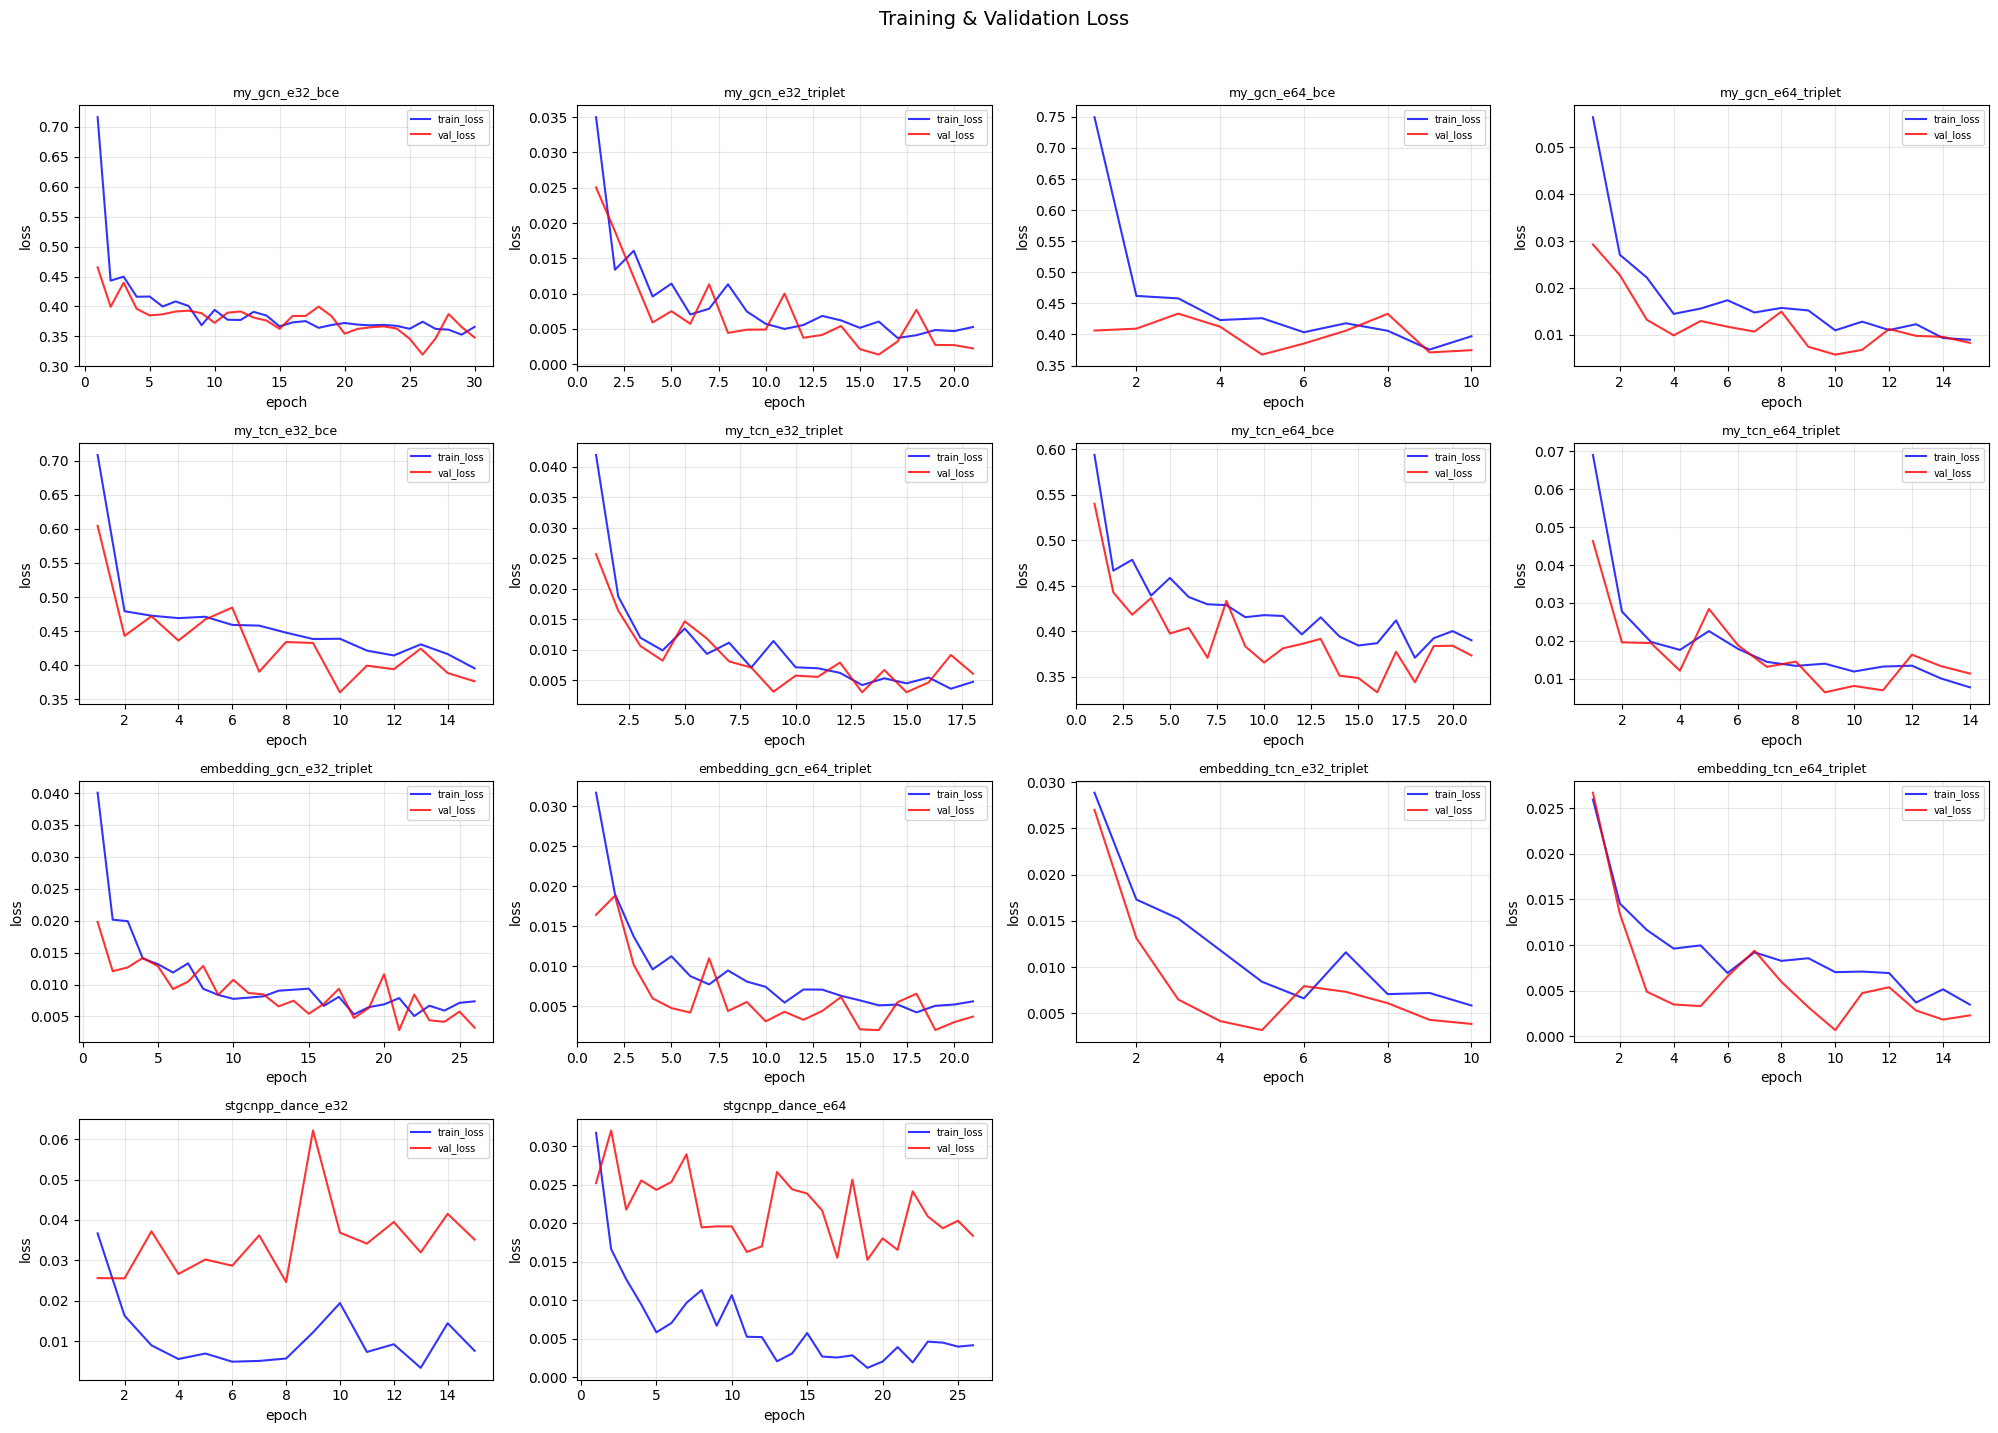

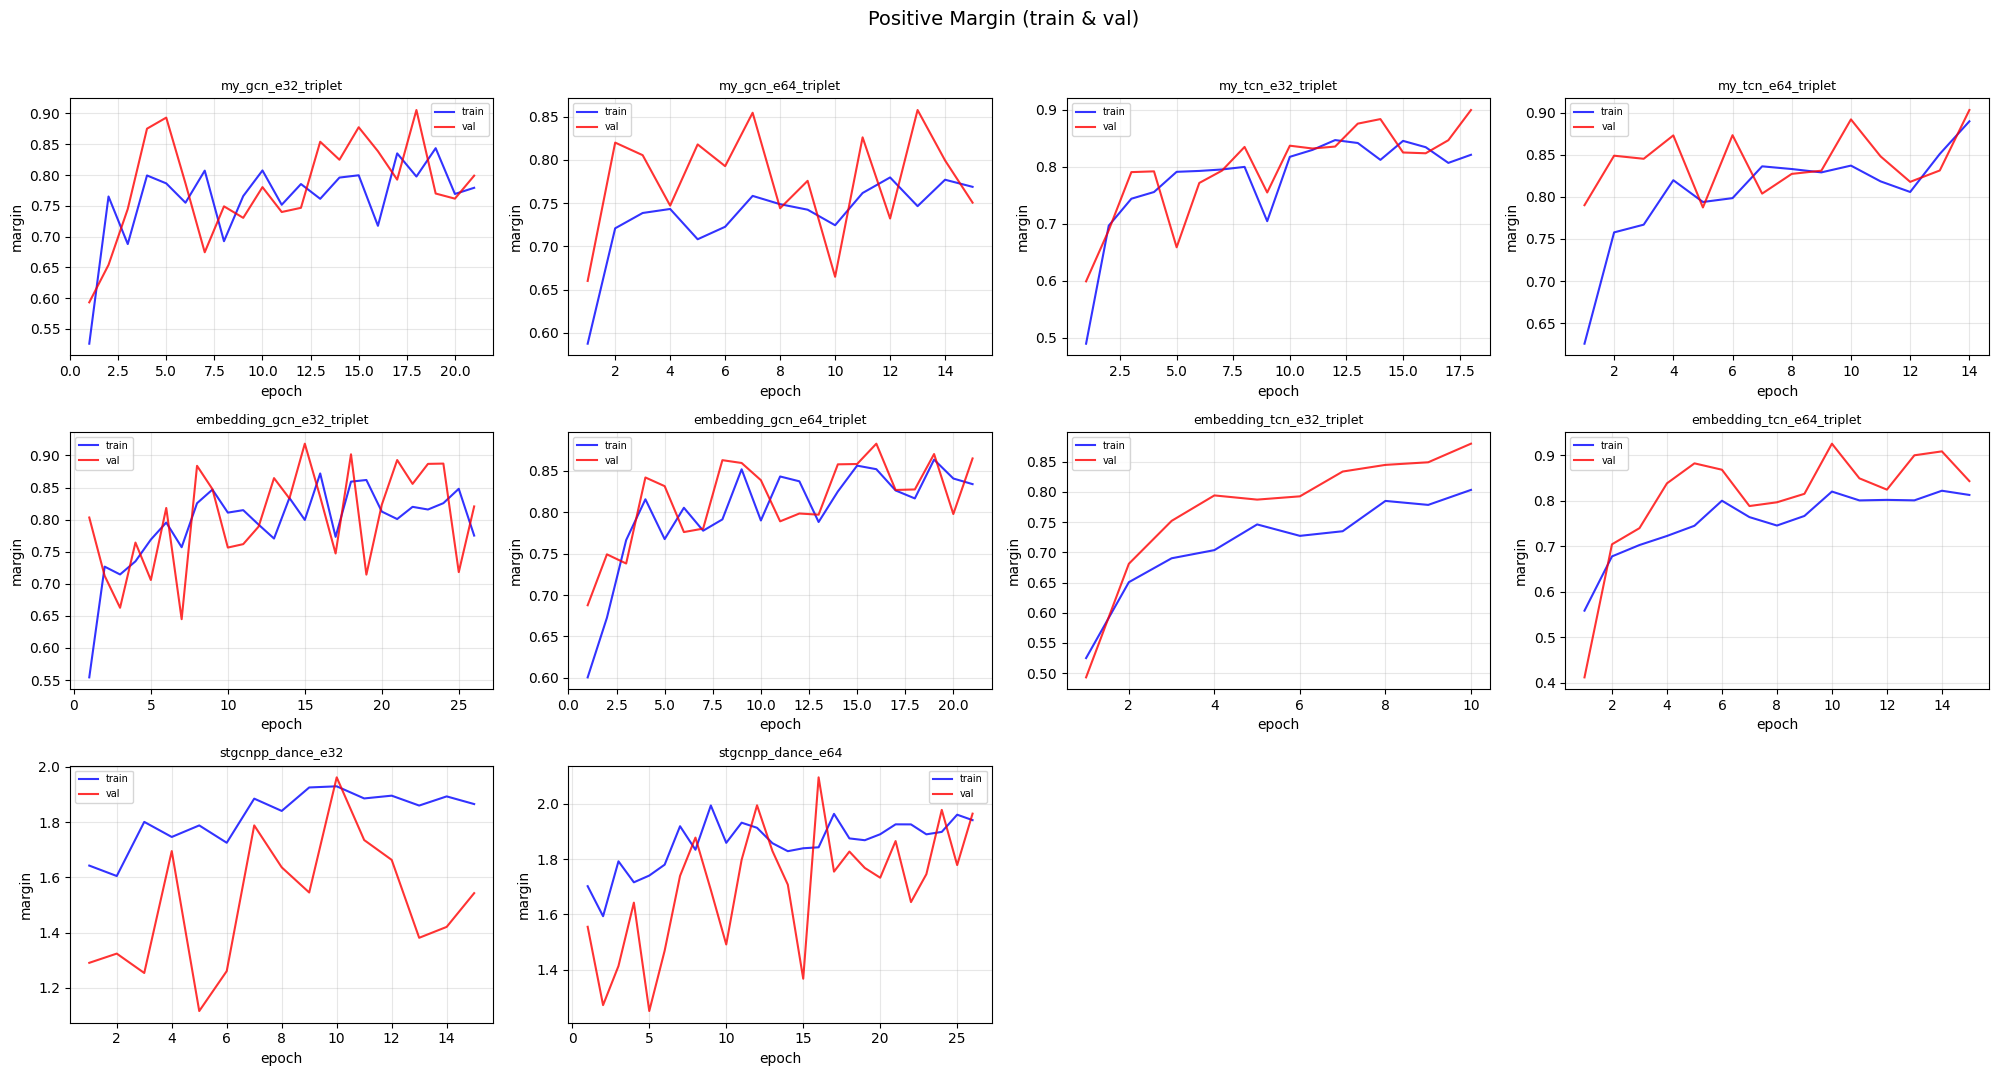

In [4]:
# Collect training histories
train_histories = []
for m in methods:
    meta = m.get('meta', {})
    hist = meta.get('history', {})
    if not hist or 'loss' not in hist:
        continue
    train_histories.append({
        'name': m['name'],
        'kind': m['kind'],
        'loss': hist.get('loss', []),
        'val_loss': hist.get('val_loss', []),
        'margin': hist.get('positive_margin', hist.get('margin', [])),
        'val_margin': hist.get('val_positive_margin', hist.get('val_margin', [])),
    })

print(f'{len(train_histories)} models with training history')

if train_histories:
    # --- Loss curves ---
    n = len(train_histories)
    cols = min(4, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows), squeeze=False)
    fig.suptitle('Training & Validation Loss', fontsize=14, y=1.02)

    for idx, h in enumerate(train_histories):
        ax = axes[idx // cols][idx % cols]
        epochs = range(1, len(h['loss']) + 1)
        ax.plot(epochs, h['loss'], 'b-', label='train_loss', alpha=0.8)
        if h['val_loss']:
            ax.plot(range(1, len(h['val_loss'])+1), h['val_loss'], 'r-', label='val_loss', alpha=0.8)
        ax.set_title(h['name'].split('::')[-1], fontsize=9)
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Hide unused axes
    for idx in range(n, rows * cols):
        axes[idx // cols][idx % cols].set_visible(False)
    plt.tight_layout()
    plt.show()

    # --- Margin curves (if available) ---
    has_margin = [h for h in train_histories if h['margin']]
    if has_margin:
        n2 = len(has_margin)
        cols2 = min(4, n2)
        rows2 = (n2 + cols2 - 1) // cols2
        fig2, axes2 = plt.subplots(rows2, cols2, figsize=(5 * cols2, 3.5 * rows2), squeeze=False)
        fig2.suptitle('Positive Margin (train & val)', fontsize=14, y=1.02)

        for idx, h in enumerate(has_margin):
            ax = axes2[idx // cols2][idx % cols2]
            epochs = range(1, len(h['margin']) + 1)
            ax.plot(epochs, h['margin'], 'b-', label='train', alpha=0.8)
            if h['val_margin']:
                ax.plot(range(1, len(h['val_margin'])+1), h['val_margin'], 'r-', label='val', alpha=0.8)
            ax.set_title(h['name'].split('::')[-1], fontsize=9)
            ax.set_xlabel('epoch')
            ax.set_ylabel('margin')
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3)

        for idx in range(n2, rows2 * cols2):
            axes2[idx // cols2][idx % cols2].set_visible(False)
        plt.tight_layout()
        plt.show()

## 3. Smoke Metrics 종합표

`_meta.json`에 저장된 smoke_metrics(same_cosine, diff_cosine, margin)를 한 표로 비교.

In [5]:
print(f'{"METHOD":<50s} {"KIND":<10s} {"LOSS":>6s} {"SAME":>7s} {"DIFF":>7s} {"MARGIN":>8s} {"EPOCH":>6s} {"KiB":>6s}')
print('-' * 102)

for m in methods:
    sm = m.get('meta', {}).get('smoke_metrics', {})
    ts = m.get('meta', {}).get('training_summary', {})
    same = sm.get('same_cosine_mean', float('nan'))
    diff = sm.get('different_cosine_mean', float('nan'))
    margin = sm.get('margin_mean', float('nan'))
    epoch = str(ts.get('best_epoch', '-'))
    size = f"{m.get('tflite_kib', 0):.0f}" if 'tflite_kib' in m else '-'
    print(f"{m['name']:<50s} {m['kind']:<10s} {m['loss']:>6s} "
          f"{same:>+7.3f} {diff:>+7.3f} {margin:>+8.3f} {epoch:>6s} {size:>6s}")

METHOD                                             KIND         LOSS    SAME    DIFF   MARGIN  EPOCH    KiB
------------------------------------------------------------------------------------------------------
direct::frame                                      direct          -    +nan    +nan     +nan      -      -
direct::window                                     direct          -    +nan    +nan     +nan      -      -
scratch::my_gcn_e32_bce                            scratch       bce    +nan    +nan     +nan      -     87
scratch::my_gcn_e32_triplet                        scratch    triplet    +nan    +nan     +nan      -     87
scratch::my_gcn_e64_bce                            scratch       bce    +nan    +nan     +nan      -    757
scratch::my_gcn_e64_triplet                        scratch    triplet    +nan    +nan     +nan      -    757
scratch::my_tcn_e32_bce                            scratch       bce    +nan    +nan     +nan      -     37
scratch::my_tcn_e32_triplet    

## 4. Pair Discrimination (Held-Out)

각 춤의 뒤 30% 구간(held-out)에서 positive/negative pair를 샘플링하고
cosine similarity 분포를 비교한다.

- **positive**: 같은 춤, 가까운 시점 (±6 frames)
- **negative**: 다른 춤
- **gap**: mean_positive - mean_negative (클수록 좋음)

In [7]:
EVAL_SEED = 42
TRAIN_RATIO = 0.7
N_PAIRS_PER_DANCE = 60
POSITIVE_JITTER = 6

rng = np.random.default_rng(EVAL_SEED)

def valid_eval_range(dance, seq_len):
    seq = references[dance]
    split = int(len(seq) * TRAIN_RATIO)
    lo = max(split + seq_len - 1, seq_len - 1)
    hi = len(seq) - 1
    return (lo, hi) if lo <= hi else None

def make_window(dance, end_idx, seq_len, feat_dims):
    return build_pose_window(references[dance], end_idx, seq_len,
                             target_joints=DANCE_JOINTS, feature_dims=feat_dims)

def sample_pairs(seq_len):
    dances = list(references.keys())
    pos, neg = [], []
    for d in dances:
        er = valid_eval_range(d, seq_len)
        if er is None:
            continue
        lo, hi = er
        for _ in range(N_PAIRS_PER_DANCE):
            ea = int(rng.integers(lo, hi + 1))
            eb = int(np.clip(ea + rng.integers(-POSITIVE_JITTER, POSITIVE_JITTER + 1), lo, hi))
            pos.append((d, ea, d, eb))
    for _ in range(len(dances) * N_PAIRS_PER_DANCE):
        da, db = rng.choice(dances, size=2, replace=False)
        era, erb = valid_eval_range(da, seq_len), valid_eval_range(db, seq_len)
        if era is None or erb is None:
            continue
        ea = int(rng.integers(era[0], era[1] + 1))
        eb = int(rng.integers(erb[0], erb[1] + 1))
        neg.append((da, ea, db, eb))
    return pos, neg

# Evaluate all methods
results_pair = {}
for m in methods:
    pos_pairs, neg_pairs = sample_pairs(m['seq_len'])
    embed_fn = m['embed_fn']
    fd = m['feat_dims']
    sl = m['seq_len']

    pos_cos = []
    for da, ea, db, eb in pos_pairs:
        wa = make_window(da, ea, sl, fd)
        wb = make_window(db, eb, sl, fd)
        pos_cos.append(float(np.dot(embed_fn(wa), embed_fn(wb))))

    neg_cos = []
    for da, ea, db, eb in neg_pairs:
        wa = make_window(da, ea, sl, fd)
        wb = make_window(db, eb, sl, fd)
        neg_cos.append(float(np.dot(embed_fn(wa), embed_fn(wb))))

    results_pair[m['name']] = {
        'pos': np.array(pos_cos),
        'neg': np.array(neg_cos),
        'mean_pos': float(np.mean(pos_cos)),
        'mean_neg': float(np.mean(neg_cos)),
        'gap': float(np.mean(pos_cos) - np.mean(neg_cos)),
    }
    print(f"  {m['name']:50s} pos={np.mean(pos_cos):+.3f}  neg={np.mean(neg_cos):+.3f}  gap={np.mean(pos_cos)-np.mean(neg_cos):+.3f}")

  direct::frame                                      pos=+0.496  neg=+0.140  gap=+0.356
  direct::window                                     pos=+0.521  neg=+0.158  gap=+0.363
  scratch::my_gcn_e32_bce                            pos=+0.911  neg=+0.022  gap=+0.889
  scratch::my_gcn_e32_triplet                        pos=+0.963  neg=+0.070  gap=+0.893
  scratch::my_gcn_e64_bce                            pos=+0.927  neg=-0.011  gap=+0.938
  scratch::my_gcn_e64_triplet                        pos=+0.953  neg=+0.329  gap=+0.624
  scratch::my_tcn_e32_bce                            pos=+0.949  neg=-0.008  gap=+0.957
  scratch::my_tcn_e32_triplet                        pos=+0.954  neg=+0.041  gap=+0.913
  scratch::my_tcn_e64_bce                            pos=+0.921  neg=-0.050  gap=+0.971
  scratch::my_tcn_e64_triplet                        pos=+0.957  neg=+0.131  gap=+0.826
  embedding::embedding_gcn_e32_triplet               pos=+0.939  neg=+0.035  gap=+0.904
  embedding::embedding_gcn_e64_t

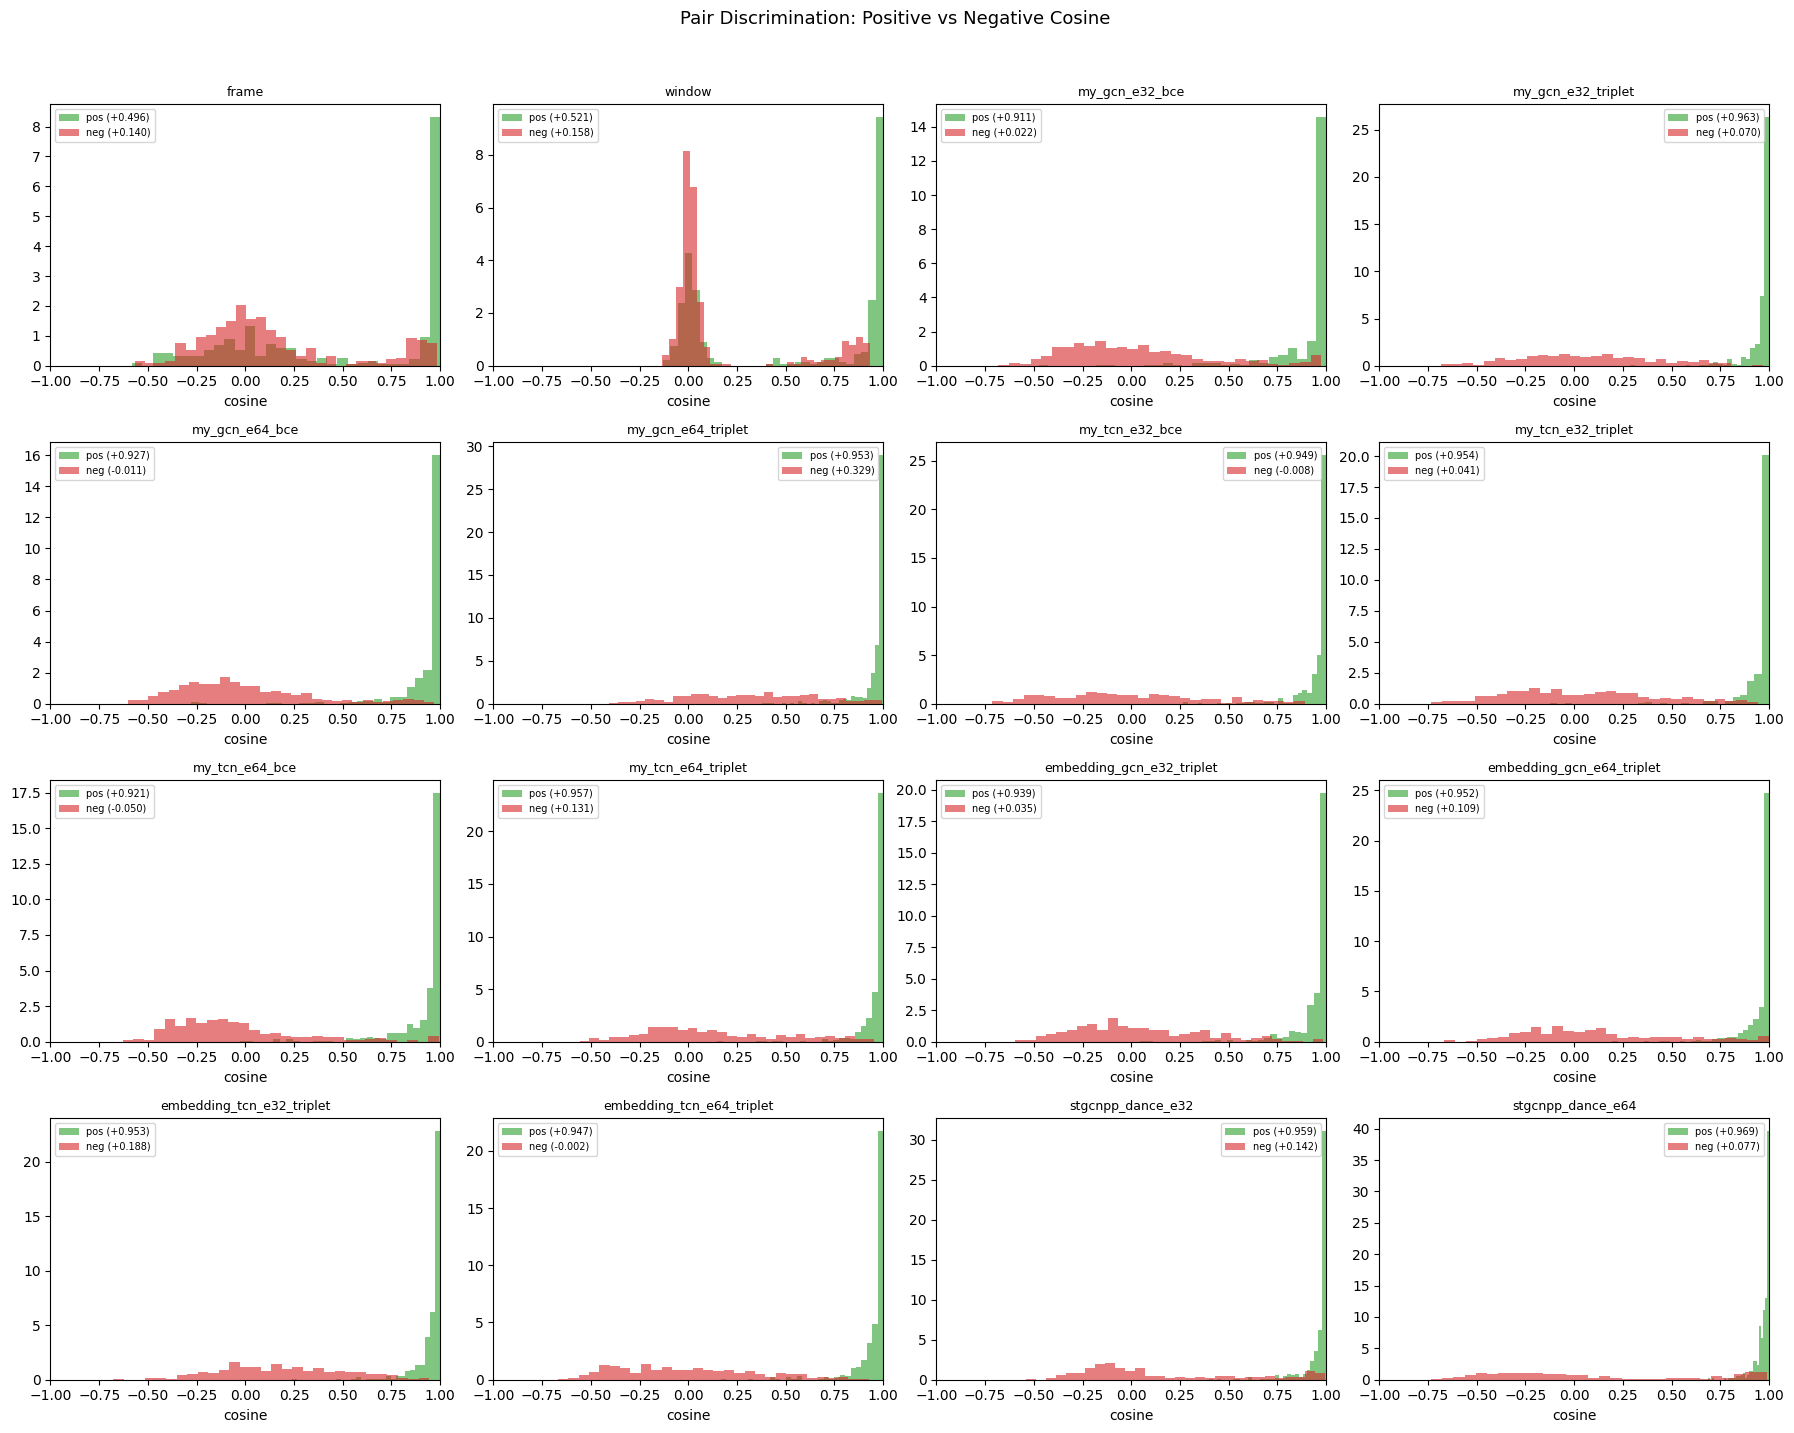

In [8]:
# --- Positive vs Negative cosine distribution histograms ---
n = len(results_pair)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.5 * rows), squeeze=False)
fig.suptitle('Pair Discrimination: Positive vs Negative Cosine', fontsize=13, y=1.02)

for idx, (name, r) in enumerate(results_pair.items()):
    ax = axes[idx // cols][idx % cols]
    ax.hist(r['pos'], bins=30, alpha=0.6, color='tab:green', label=f"pos ({r['mean_pos']:+.3f})", density=True)
    ax.hist(r['neg'], bins=30, alpha=0.6, color='tab:red', label=f"neg ({r['mean_neg']:+.3f})", density=True)
    ax.set_title(name.split('::')[-1], fontsize=9)
    ax.set_xlabel('cosine')
    ax.legend(fontsize=7)
    ax.set_xlim(-1, 1)

for idx in range(n, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Temporal Smoothness

held-out 구간에서 연속된 window를 stride=1로 추출, `cos(E(t), E(t+k))`를 k에 따라 측정.
매끄럽게 감소하면 motion 연속성을 잘 반영하는 것.

In [9]:
SMOOTH_KS = [1, 5, 15, 30]
SMOOTH_SEGMENT = 200

results_smooth = {}
for m in methods:
    sl, fd = m['seq_len'], m['feat_dims']
    embed_fn = m['embed_fn']
    per_k = {k: [] for k in SMOOTH_KS}

    for dance in references:
        er = valid_eval_range(dance, sl)
        if er is None:
            continue
        lo, hi = er
        seg_end = min(lo + SMOOTH_SEGMENT, hi)
        if seg_end - lo < max(SMOOTH_KS):
            continue

        embeddings = []
        for t in range(lo, seg_end + 1):
            w = make_window(dance, t, sl, fd)
            embeddings.append(embed_fn(w))
        embeddings = np.array(embeddings)

        for k in SMOOTH_KS:
            if k >= len(embeddings):
                continue
            cos_vals = np.sum(embeddings[:-k] * embeddings[k:], axis=1)
            per_k[k].extend(cos_vals.tolist())

    results_smooth[m['name']] = {k: float(np.mean(v)) if v else float('nan') for k, v in per_k.items()}
    vals = '  '.join(f'k={k}: {results_smooth[m["name"]][k]:+.3f}' for k in SMOOTH_KS)
    print(f"  {m['name'].split('::')[-1]:40s} {vals}")

  frame                                    k=1: +0.459  k=5: +0.431  k=15: +0.393  k=30: +0.375
  window                                   k=1: +0.463  k=5: +0.418  k=15: +0.364  k=30: +0.356
  my_gcn_e32_bce                           k=1: +0.984  k=5: +0.903  k=15: +0.707  k=30: +0.472
  my_gcn_e32_triplet                       k=1: +0.989  k=5: +0.928  k=15: +0.755  k=30: +0.553
  my_gcn_e64_bce                           k=1: +0.983  k=5: +0.866  k=15: +0.598  k=30: +0.360
  my_gcn_e64_triplet                       k=1: +0.992  k=5: +0.927  k=15: +0.747  k=30: +0.550
  my_tcn_e32_bce                           k=1: +0.984  k=5: +0.898  k=15: +0.631  k=30: +0.343
  my_tcn_e32_triplet                       k=1: +0.987  k=5: +0.919  k=15: +0.705  k=30: +0.439
  my_tcn_e64_bce                           k=1: +0.986  k=5: +0.888  k=15: +0.582  k=30: +0.407
  my_tcn_e64_triplet                       k=1: +0.989  k=5: +0.926  k=15: +0.718  k=30: +0.543
  embedding_gcn_e32_triplet             

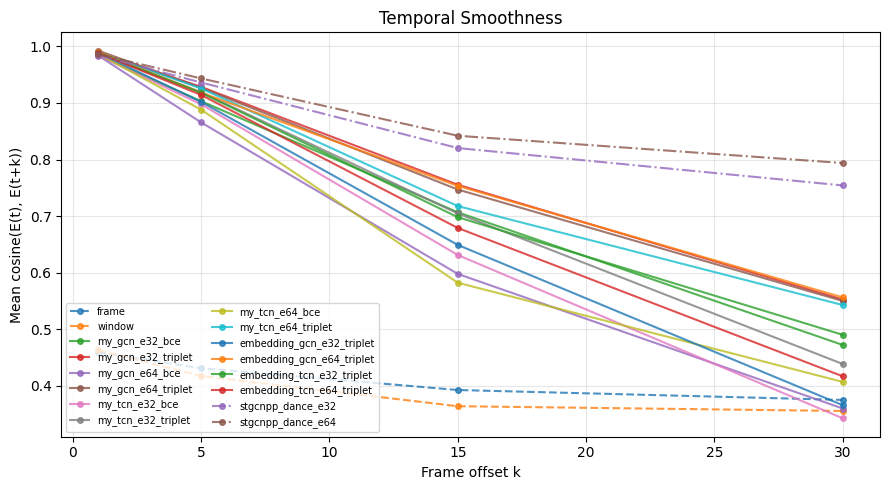

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
kind_styles = {'direct': '--', 'scratch': '-', 'embedding': '-', 'stgcnpp': '-.'}
kind_colors = {'direct': 'gray', 'scratch': None, 'embedding': None, 'stgcnpp': None}

for m in methods:
    vals = results_smooth[m['name']]
    ks = sorted(vals.keys())
    ys = [vals[k] for k in ks]
    style = kind_styles.get(m['kind'], '-')
    label = m['name'].split('::')[-1]
    ax.plot(ks, ys, style, marker='o', markersize=4, label=label, alpha=0.8)

ax.set_xlabel('Frame offset k')
ax.set_ylabel('Mean cosine(E(t), E(t+k))')
ax.set_title('Temporal Smoothness')
ax.legend(fontsize=7, ncol=2, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Noise Robustness

clean window에 Gaussian noise를 추가했을 때 embedding이 얼마나 유지되는지 측정.

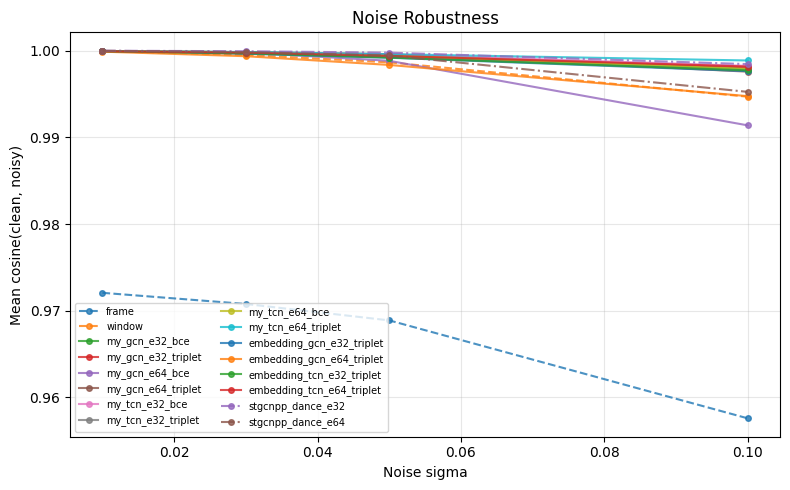

In [11]:
NOISE_SIGMAS = [0.01, 0.03, 0.05, 0.1]
N_NOISE_WINDOWS = 40

results_noise = {}
for m in methods:
    sl, fd = m['seq_len'], m['feat_dims']
    embed_fn = m['embed_fn']
    per_sigma = {s: [] for s in NOISE_SIGMAS}

    for dance in references:
        er = valid_eval_range(dance, sl)
        if er is None:
            continue
        lo, hi = er
        for _ in range(N_NOISE_WINDOWS // len(references)):
            end = int(rng.integers(lo, hi + 1))
            w_clean = make_window(dance, end, sl, fd)
            e_clean = embed_fn(w_clean)
            for sigma in NOISE_SIGMAS:
                w_noisy = w_clean + rng.normal(0, sigma, w_clean.shape).astype(np.float32)
                e_noisy = embed_fn(w_noisy)
                per_sigma[sigma].append(float(np.dot(e_clean, e_noisy)))

    results_noise[m['name']] = {s: float(np.mean(v)) if v else float('nan') for s, v in per_sigma.items()}

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for m in methods:
    vals = results_noise[m['name']]
    sigmas = sorted(vals.keys())
    ys = [vals[s] for s in sigmas]
    style = kind_styles.get(m['kind'], '-')
    ax.plot(sigmas, ys, style, marker='o', markersize=4, label=m['name'].split('::')[-1], alpha=0.8)

ax.set_xlabel('Noise sigma')
ax.set_ylabel('Mean cosine(clean, noisy)')
ax.set_title('Noise Robustness')
ax.legend(fontsize=7, ncol=2, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 종합 비교표

In [ ]:
header_cols = [
    ('METHOD', 50),
    ('KIND', 10),
    ('POS', 7),
    ('NEG', 7),
    ('GAP', 8),
    ('SM@15', 7),
    ('NR@.05', 7),
    ('KiB', 6),
]

header = '  '.join(f'{col:<{w}s}' if col == 'METHOD' else f'{col:>{w}s}' for col, w in header_cols)
print(header)
print('-' * len(header))

rows_data = []
for m in methods:
    r = results_pair[m['name']]
    sm15 = results_smooth[m['name']].get(15, float('nan'))
    nr05 = results_noise[m['name']].get(0.05, float('nan'))
    size = f"{m.get('tflite_kib', 0):.0f}" if 'tflite_kib' in m else '-'

    row = [
        f"{m['name']:<50s}",
        f"{m['kind']:>10s}",
        f"{r['mean_pos']:>+7.3f}",
        f"{r['mean_neg']:>+7.3f}",
        f"{r['gap']:>+8.3f}",
        f"{sm15:>+7.3f}",
        f"{nr05:>+7.3f}",
        f"{size:>6s}",
    ]
    print('  '.join(row))
    rows_data.append({'name': m['name'], 'kind': m['kind'], 'gap': r['gap'], 'sm15': sm15, 'nr05': nr05})

print()
best = max(rows_data, key=lambda x: x['gap'])
print(f"Best GAP: {best['name']}  (gap={best['gap']:+.3f})")